# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behaviour and predict whether a client will subscribe to a term deposit.

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
# Check for missing values and data types
print('Shape:', df.shape)
print('\n--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())

Shape: (41188, 21)

--- Data Types ---
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

--- Missing Values ---
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m        

In [4]:
# Summary statistics
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


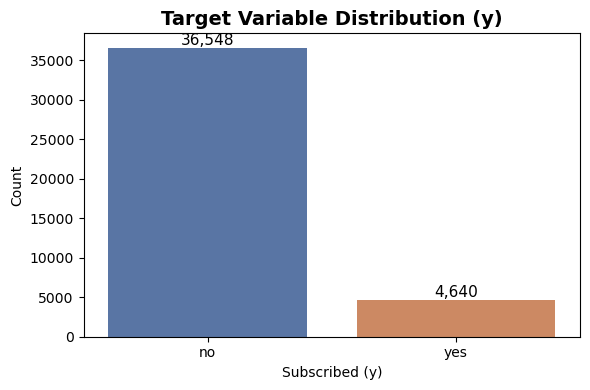

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable
counts = df['y'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=['#4C72B0','#DD8452'], legend=False, ax=ax)
ax.set_title('Target Variable Distribution (y)', fontsize=14, fontweight='bold')
ax.set_xlabel('Subscribed (y)')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

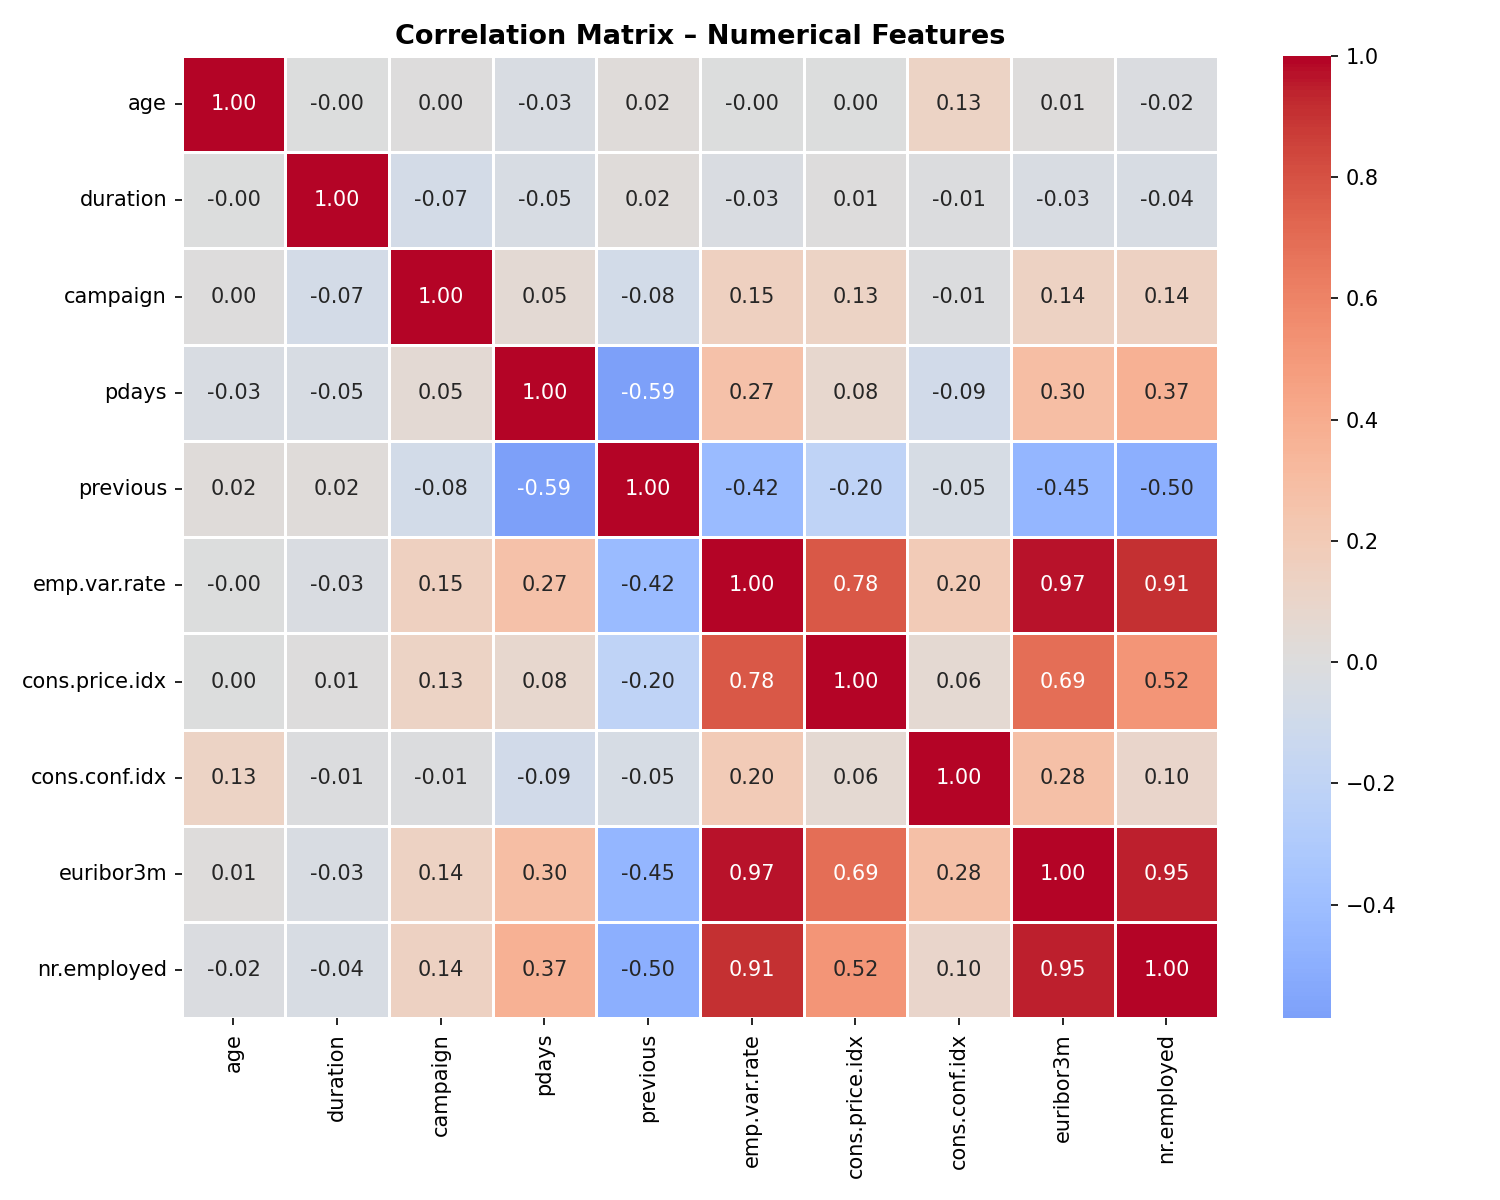

In [5]:
# Correlation matrix for numerical features
num_df = df.select_dtypes(include='number')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix – Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

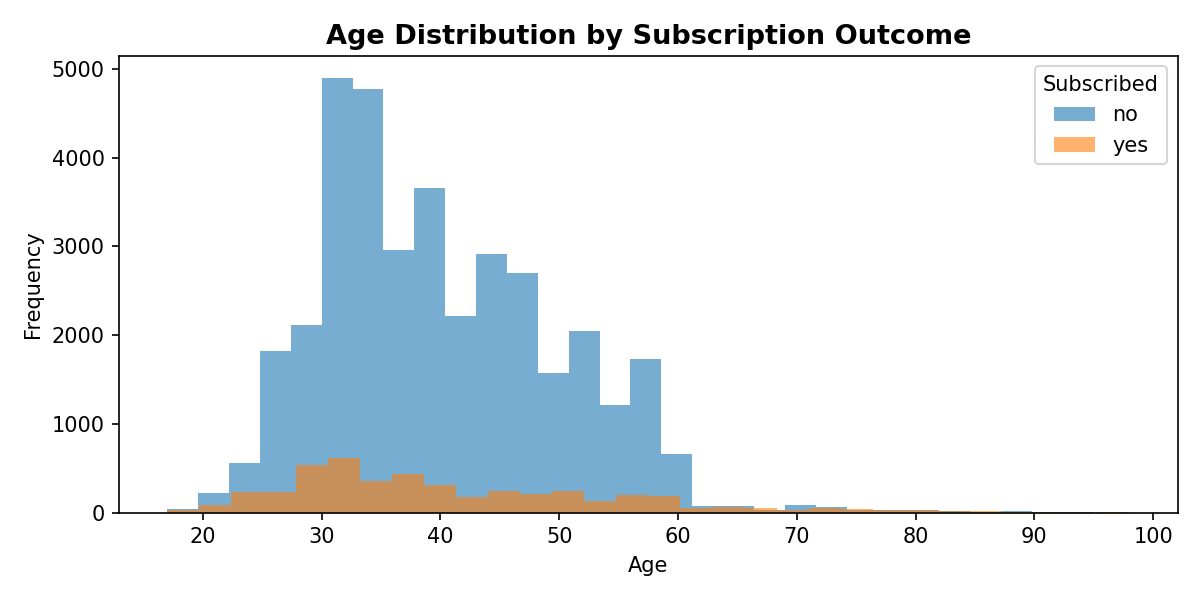

In [6]:
# Age distribution by subscription outcome
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby('y'):
    grp['age'].plot.hist(bins=30, alpha=0.6, label=label, ax=ax)
ax.set_title('Age Distribution by Subscription Outcome', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.legend(title='Subscribed')
plt.tight_layout()
plt.show()

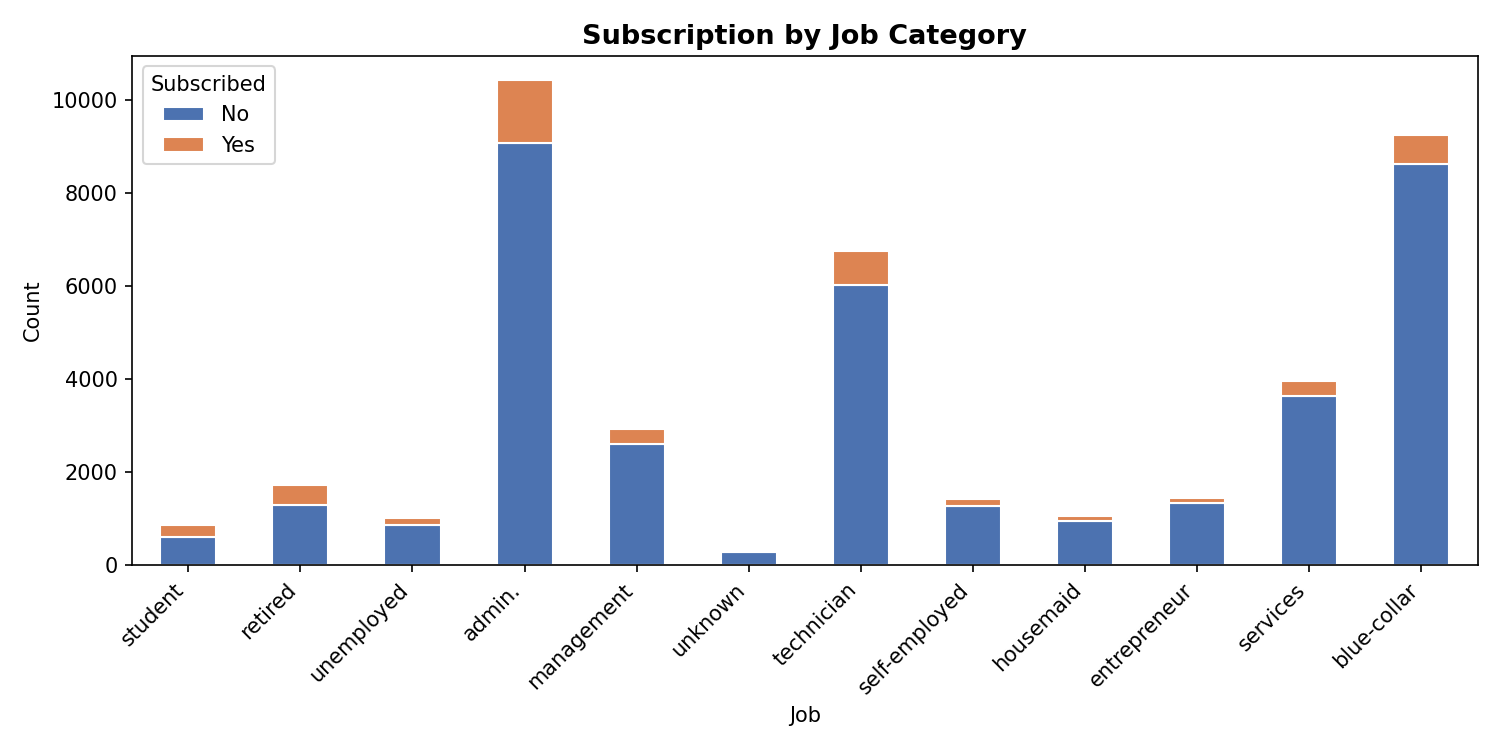

In [7]:
# Job category vs subscription
job_sub = df.groupby(['job','y']).size().unstack(fill_value=0)
job_sub['rate'] = job_sub['yes'] / job_sub.sum(axis=1)
job_sub = job_sub.sort_values('rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
job_sub[['no','yes']].plot(kind='bar', stacked=True, ax=ax,
                           color=['#4C72B0','#DD8452'], edgecolor='white')
ax.set_title('Subscription by Job Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Job')
ax.set_ylabel('Count')
ax.legend(['No','Yes'], title='Subscribed')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Conclusion

In this analysis, we explored the structure and composition of the bank marketing dataset. Key takeaways include:

- **No missing values** — the dataset is clean across all 41,188 rows and 21 columns.
- **Class imbalance** — ~88.7% of customers did not subscribe (`no`), confirming the imbalanced nature of the target variable `y`.
- **Strong macro-economic correlations** — `euribor3m`, `emp.var.rate`, and `nr.employed` are highly correlated with each other, indicating multicollinearity that should be addressed before modelling.
- **Call duration matters** — `duration` has the highest individual correlation with the outcome, but since it is only known after the call, it should be excluded from predictive models to avoid data leakage.
- **Retired & student customers** show the highest subscription rates by job category.
- **Further steps** — preprocessing (encoding categoricals, handling `pdays=999`), feature engineering, and model training (Logistic Regression, Random Forest, XGBoost) are the natural next steps.